In [1]:
%load_ext autoreload
%autoreload 2
%cd ../..

/home/philippe/MolGenDocking


In [2]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from tqdm import tqdm

warnings.filterwarnings("ignore")

from notebooks.utils import *

## Loading

In [3]:
MOLSTRAL_PATH = Path("MolGenOutput/test_ood")
FIG_PATH = "MolGenDocking-latex/Figures/Results/MolGen"
os.makedirs(FIG_PATH, exist_ok=True)

files = [f for d in MOLSTRAL_PATH.iterdir() for f in d.iterdir() if "" in str(f) and str(f).endswith("_scored.jsonl")]
# files = [Path("MolGenOutput/test_ood/RL-Mistral-24B-100/RL-Mistral-24B-100_0_scored.jsonl")]
files = sorted(files)[::-1]

print("Total files:", len(files))
save_df_path = Path("MolGenOutput/test_ood.csv")
if save_df_path.exists():
    df = pd.read_csv(save_df_path)
else:
    df = load_molgen_results(files[:])
    df.to_csv(save_df_path, index=False)

Total files: 130


In [5]:
df.groupby("model").prompt_id.count()

model
ChemDFM-R-14B                    128000
ChemDFM-v2.0-14B                 128000
DeepSeek-R1-Distill-Llama-70B    128000
DeepSeek-R1-Distill-Qwen-32B     128000
Llama-3.3-70B-Instruct           128000
MiniMax-M2                       128000
Mistral-Small-4-128B             128000
Qwen3-30B-A3B-Thinking-2507      128000
Qwen3-Next-80B-A3B-Thinking      128000
RL-Mistral-24B                   128000
RL-Molstral-g16                   63993
RL-Molstral-g4                    42940
RL-Molstral-g8                    63994
ZINC                             128000
ether0                           128000
gemma-3-27b-it                   128000
gemma-4-31B-it                   128000
gpt-oss-120b                     128000
Name: prompt_id, dtype: int64

In [12]:
df = df[df.Model != "RL-Mistral"]

In [13]:
sub_sample_prompts = df[df.Model == "gemma-4"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]

sub_sample_prompts = df[df.Model == "RL-Molstral-g4"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]

sub_sample_prompts = df[df.Model == "Mistral-Small-4"].prompt_id.unique()[:]
df = df[df.prompt_id.isin(sub_sample_prompts)]


In [14]:
df.groupby(["Model", "prompt_id"]).valid.count().reset_index().groupby("Model").valid.sum()

Model
ChemDFM-R          42273
ChemDFM-v2.0       42273
Llama-3.3          42273
MiniMax-M2         42273
Mistral-Small-4    42273
Qwen3              42273
Qwen3-Next         42273
R1-Llama           42273
R1-Qwen            42273
RL-Molstral-g16    42273
RL-Molstral-g4     42273
RL-Molstral-g8     42273
ZINC               42273
ether0             42273
gemma-3            42273
gemma-4            42273
gpt-oss            42273
Name: valid, dtype: int64

In [15]:
min_vals = df.groupby(["Model", "prompt_id"]).reward.count().reset_index().groupby("Model").reward.min().min()

df = df.groupby(["Model", "prompt_id"]).sample(min_vals, random_state=42).reset_index()
df

,level_0,index,prompt_id,reward,model,n_props,properties,objectives,smiles,validity,valid,Model
0,61,2028351,107210,0.00000,ChemDFM-R-14B,1,2woq_AYC_A_1333,minimize,C[C@H]1CCN1Cc1cc(C(=O)N[C@H](CN(C)C)c2ccc(Cl)c...,1,valid,ChemDFM-R
1,57,2028408,107210,0.57400,ChemDFM-R-14B,1,2woq_AYC_A_1333,minimize,NCCc1c[nH]c2ccccc12,1,valid,ChemDFM-R
2,0,2028390,107210,0.75875,ChemDFM-R-14B,1,2woq_AYC_A_1333,minimize,O=C(O)CCCCC(Nc1ccc([N+](=O)[O-])cc1)C(=O)O,1,valid,ChemDFM-R
3,43,2028365,107210,0.00000,ChemDFM-R-14B,1,2woq_AYC_A_1333,minimize,Cc1c(C(=O)O)c2c(-c3cc4ccccc4s3)cccc2n1CCCN1CCOCC1,1,valid,ChemDFM-R
4,5,2028391,107210,0.00000,ChemDFM-R-14B,1,2woq_AYC_A_1333,minimize,NaN,0,no answer,ChemDFM-R
...,...,...,...,...,...,...,...,...,...,...,...,...
558938,760880,38002,9853-106,0.00000,gpt-oss-120b,1,5f1r_42O_A_301,below,NaN,0,no SMILES,gpt-oss
558939,760910,37984,9853-106,0.00000,gpt-oss-120b,1,5f1r_42O_A_301,below,NaN,0,multiple SMILES,gpt-oss
558940,760890,37901,9853-106,0.00000,gpt-oss-120b,1,5f1r_42O_A_301,below,O=C(Nc1ncnc2c1cc(cc2)F)C(N3CCOCC3)C(=O)NCC4=CC...,1,valid,gpt-oss
558941,760912,37940,9853-106,0.00000,gpt-oss-120b,1,5f1r_42O_A_301,below,O=S(=O)(N(C)C)C1=NC2=CC=CC=C2N=C1N(C)C,1,valid,gpt-oss


In [16]:
min_vals

49

# Validity Plot

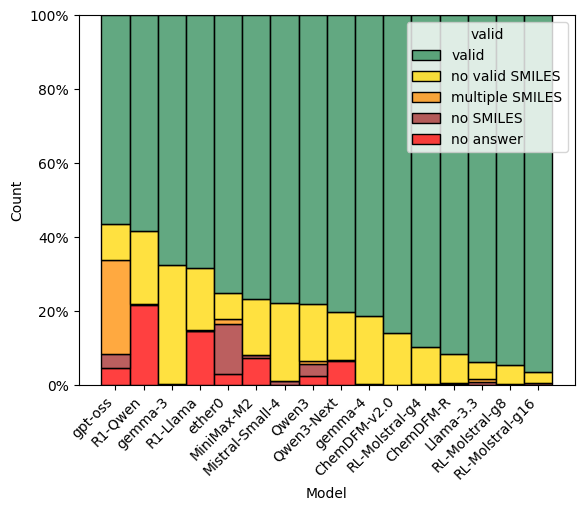

In [20]:
cmap = {
    "valid": "seagreen",
    "no valid SMILES": "gold",
    "multiple SMILES": "darkorange",
    "no SMILES": "brown",
    "no answer": "red"
}
x_order = df[df.Model != "ZINC"].groupby("Model").validity.mean().sort_values().index
ax = sns.histplot(data=df[df.Model != "ZINC"].set_index("Model").loc[x_order].reset_index(), x="Model", hue="valid", multiple="stack", stat="count", palette= cmap, hue_order=list(cmap.keys()))
# rotate x labels
max_count = min_vals * df.prompt_id.nunique()
ax.set_ylim(0, max_count)

yticks = np.linspace(0, max_count, 6)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(y / max_count * 100)}%" for y in yticks])
_ = plt.xticks(rotation=45, ha='right')
# Replace y_ticks with percentages from 0 to 100

plt.savefig(f"{FIG_PATH}/validity.pdf", bbox_inches='tight')

# Uniqueness and Diversity Metrics

In [21]:
import re

valid_smiles_pattern = re.compile(r"^[A-Za-z0-9=#:\+\-\[\]\(\)/\\@.%]+$")
mkd_pattern = re.compile(r"^(\*\*|[-*'])(.+)\1$")

def get_mol(smi):
    if not isinstance(smi, str):
        return None
    smi = smi.strip()
    m = mkd_pattern.match(smi)
    x = m.group(2) if m else smi
    return Chem.MolFromSmiles(x)



df["Mol"] = df["smiles"].progress_apply(get_mol)
df["CanSMI"] = df["Mol"].progress_apply(lambda x: None if x is None else Chem.MolToSmiles(x))


100%|██████████| 558943/558943 [00:44<00:00, 12641.22it/s]


## Computations

Compute the uniqueness of the generated smiles in each prompt

In [22]:
uniq_df = df[df.validity == 1].groupby(["Model", "prompt_id"]).agg(
    **{f"{k}":pd.NamedAgg(column="CanSMI", aggfunc=aggregate_molgen_fn("uniqueness", k)) for k in list(range(1,100,10))}
).reset_index()
uniq_df = uniq_df.melt(id_vars=["Model"], value_vars=[str(k) for k in list(range(1,100,10))], var_name="n_rollout")
uniq_df["n_rollout"] = uniq_df["n_rollout"].apply(int)

Diversity in each prompt (ecfp4)

In [23]:
fp_fn = fp_name_to_fn("ecfp4-2048")

sub_df = df[df.Mol.apply(lambda x: x is not None)].drop_duplicates(subset=["prompt_id", "CanSMI"])
sub_df["fps"] = sub_df["Mol"].progress_apply(fp_fn)

sim_df = sub_df.groupby(["Model", "prompt_id"]).agg(
    **{
        f"{k}":pd.NamedAgg(
            column="fps",
            aggfunc=aggregate_molgen_fn("diversity",k, is_fp=True))
        for k in [50]
    }
).reset_index()
sim_df = sim_df.melt(id_vars=["Model"], value_vars=[str(k) for k in [50]], var_name="n_rollout")
sim_df["n_rollout"] = sim_df["n_rollout"].apply(int)

100%|██████████| 389429/389429 [02:23<00:00, 2722.96it/s] 


## Plots

In [26]:
uniq_df = uniq_df[uniq_df.Model != "ZINC"]
uniq_df["Proportion of duplicates"] = 1- uniq_df["value"]

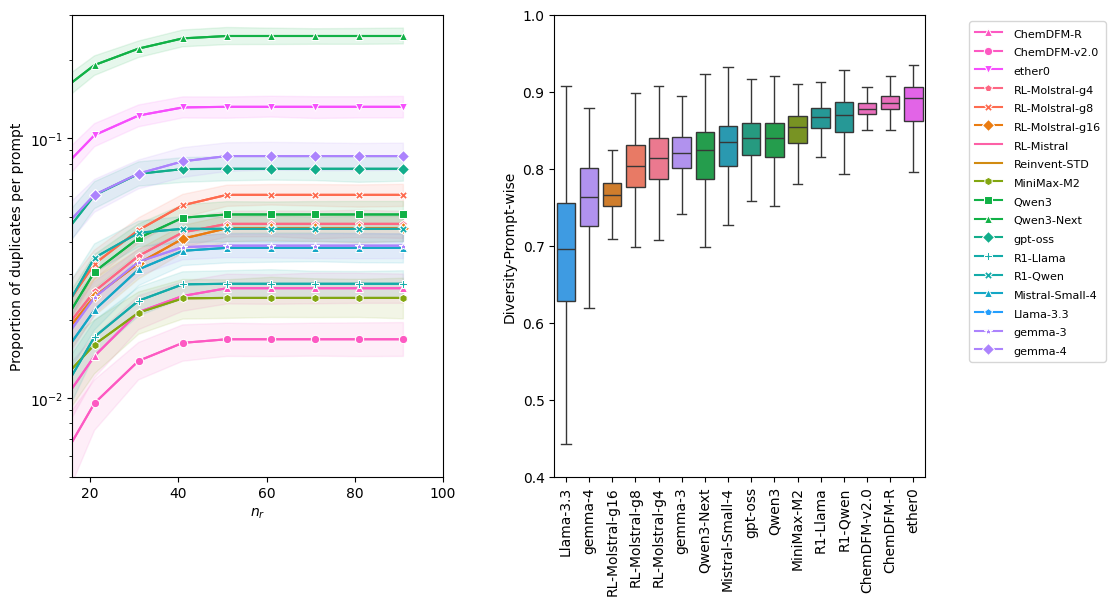

In [36]:
from notebooks.utils import CMAP_MODELS, MARKER_MODELS

fig, axes = plt.subplots(1, 2, figsize=(11,6), sharey=False, gridspec_kw={"wspace":0.3})

ax = axes[0]
sns.lineplot(uniq_df, x="n_rollout", y="Proportion of duplicates", hue="Model", ax=ax, legend=False, palette=CMAP_MODELS, hue_order=CMAP_MODELS.keys(), err_kws={"alpha":0.1})
sns.lineplot(uniq_df[uniq_df.n_rollout % 10 == 1], x="n_rollout", y="Proportion of duplicates", hue="Model", ax=ax, legend=True, palette=CMAP_MODELS, hue_order=CMAP_MODELS.keys(), errorbar=None, style="Model", dashes=False, markers = MARKER_MODELS)

ax.set_ylabel("Proportion of duplicates per prompt")
ax.set_xlabel("$n_r$")
ax.set_ylim(0.005,0.3)
ax.set_xlim(16,100)
ax.set_yscale("log")
# Move legend below plot
legend = ax.legend(bbox_to_anchor=(2.4, 1.0), loc='upper left', ncols=1)
# Make legend smaller
for text in legend.get_texts():
    text.set_fontsize(8)

ax = axes[1]
x_order = sim_df[sim_df.Model != "ZINC"].groupby("Model")["value"].median().sort_values().index.tolist()
sns.boxplot(sim_df[sim_df.Model != "ZINC"], x="Model", y="value", hue="Model", ax=ax, legend = False, order=x_order, palette=CMAP_MODELS,fliersize=0)
ax.set_ylabel("Diversity-Prompt-wise")
ax.set_xlabel("")
# rotate x ticks
ax.set(ylim=(0.4,1))
# ax.set_yscale("log")
ax.tick_params(axis='x', rotation=90)

fig.savefig(f"{FIG_PATH}/uniqueness_diversity.pdf", bbox_inches='tight')

# Top-k scores after RL

In [37]:
64/6

10.666666666666666

In [38]:
k_values = [2,6]
topk_dfs = []
MODELS=[
    "RL-Molstral-g4",
    "RL-Molstral-g8",
    "RL-Molstral-g16",
    "Mistral-Small-4"
]
n_div_k = {
    k:  [1.2,2,4,8] for k in k_values
}
pbar = tqdm(total=3*sum(len(v) for v in n_div_k.values()))

for k in k_values:
    for _ in range(3):
        roll_values = [int(v * k) for v in n_div_k[k]]
        k_topk_dfs = []
        for roll in roll_values:
            topdf = df[
                df.Model.isin(
                    MODELS)
            ].groupby(
                ["Model", "prompt_id"]
            ).apply(
                aggregate_molgen_fn("topk", k=k, n_rollout=roll)
            ).to_frame().rename(columns={0:f"{roll}"}).reset_index()
            k_topk_dfs.append(
                topdf
            )
            pbar.update(1)

        topk_df = pd.concat(k_topk_dfs).reset_index(drop=True)
        topk_df["k"] = k
        topk_df = topk_df.melt(id_vars=["prompt_id","Model", "k"], value_vars=[str(k) for k in roll_values], var_name="n_rollout", value_name= "top-k")
        topk_df["n_rollout"] = topk_df["n_rollout"].apply(int)

        topk_dfs.append(topk_df)
pbar.close()
topk_df = pd.concat(topk_dfs).reset_index(drop=True)

topk_df["$n_r$ / k"] = topk_df["n_rollout"] / topk_df["k"]

  0%|          | 0/24 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Get diversity_df
from molrgen.evaluation.fingeprints_utils import get_sim_matrix
from scipy.spatial.distance import squareform

QUANTILES = (1-np.power(10, np.linspace(np.log10(0.3), np.log10(0.02), 10).astype(float)))
print(QUANTILES)

def get_quantile_nn(mols, quantiles = QUANTILES):
    sim_matrix = get_sim_matrix(mols, fingerprint_name= "ecfp4-1024")
    sim_matrix = squareform(sim_matrix)
    sim_matrix = sim_matrix + np.eye(len(sim_matrix))
    return [np.quantile(sim_matrix, q, axis = 1).mean() for q in quantiles]

sub_df_m = df[df.Model.isin(MODELS) & (df.Mol.apply(lambda x: x is not None))]

div_df_grpo = sub_df_m.groupby(["Model","prompt_id"]).Mol.apply(get_quantile_nn).to_frame().rename(columns={"Mol":"Tanimoto Sim."})
div_df_grpo["quantile"] = [QUANTILES for _ in range(len(div_df_grpo))]
div_df_grpo = div_df_grpo.explode(["Tanimoto Sim.", "quantile"]).reset_index()

In [ ]:
fig_size = 2.7
aspect = 1.7


fig = plt.figure(figsize=(fig_size,fig_size*aspect))

gs_top = fig.add_gridspec(1, 1, top=0.7, bottom=0.35)
ax_main = fig.add_subplot(gs_top[0, 0])
sns.lineplot(
    topk_df.groupby(
        ["Model", "k", "$n_r$ / k"]
    )["top-k"].mean().reset_index(),
    x="$n_r$ / k",
    y="top-k",
    hue="Model",
    style="Model",
    palette=CMAP_MODELS,
    markers=MARKER_MODELS,
    dashes=False,
    markersize=7,
    ax=ax_main,
    errorbar=None,
    hue_order=sorted(topk_df.Model.unique(), key=lambda x: list(CMAP_MODELS.keys()).index(x))
)
ax_main.set_xscale('log', base=2)
ax_main.set_xticks([1, 2, 4])
ax_main.set_xticklabels(['1', '2', '4'], size=8)
ax_main.set_xlabel("$n_r$ / k", loc="center", labelpad=-0.1)
ax_main.set_ylabel("top-k@$n_r$ score", labelpad=-0.1)
ax_main.set_xlim(1,8)
ax_main.grid()
# Make legend smaller and position it
legend = ax_main.legend(fontsize=9, ncols=1, frameon=True)
legend.get_frame().set_alpha(0.95)


gs_bottom = fig.add_gridspec(1, 1, top=0.23, bottom=0.)
ax_sim_plot = fig.add_subplot(gs_bottom[0, 0])
sns.lineplot(div_df_grpo, x="quantile", y="Tanimoto Sim.", hue="Model", palette=CMAP_MODELS, ax=ax_sim_plot, legend=False, style="Model", dashes=False, markers=MARKER_MODELS, markersize=7)
ax_sim_plot.set_xlim(QUANTILES[0], QUANTILES[-1])

ax_sim_plot.set_yscale('log', base=10)
ax_sim_plot.set_xscale('log', base=10)

# ticks
ax_sim_plot.set_yticks(
    [
        0.2,0.3,0.4, 0.5, 0.6
    ],
    labels = [
        0.2,0.3,0.4,0.5, 0.6
    ]
)
ax_sim_plot.set_xticks(
    [0.7, 0.75, 0.8, 0.85, 0.9, 0.95],
    labels = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
)


ax_sim_plot.grid()


plt.savefig(f"{FIG_PATH}/topk_mosaic.pdf", bbox_inches='tight')
plt.show()

# Tables for Top-k

In [39]:
from notebooks.metadata.molgen import MODEL_META
from notebooks.utils import aggregate_molgen_fn
LATEX_PATH = "MolGenDocking-latex/tables/results"

MODEL_ORDER = [
    # "ZINC",
    "gemma-4", #04/26
    "Mistral-Small-4", #03/26
    "MiniMax-M2",# 10/25
    "Qwen3-Next",# 09/25
    "gpt-oss",# 08/25
    "Qwen3", # 04/24
    "Llama-3.3",#04/25
    "gemma-3",#03/25
    "R1-Llama",#01/25
    "R1-Qwen",#01/25
    "ether0",
    "ChemDFM-R",
    "ChemDFM-v2.0",
    "RL-Molstral-g4",
    "RL-Molstral-g8",
    "RL-Molstral-g16",
    # "RL-Mistral",
]

In [40]:
# Create table with: model_name, size, metric_name, value
import re

Ks = [1, 16]
N_r = [16, 24, 32, 48]

N_reperform = 5

table = []
size_pattern = re.compile(r'(?i)(?:^|[-_])(\d+\s*[b])(?:$|[-_])')
pbar = tqdm(total=len(df.model.unique())*len(N_r) * len(Ks) * N_reperform)
df.model = df.model.apply(lambda x: "Mistral-Small-4-128B" if  x == "Mistral-Small-128B" else x)

for model_name in df.model.unique():
    assert any([m in model_name for m in MODEL_META.keys()]), f"Model {model_name} not found in MODEL_META"
    key = [m for m in MODEL_META.keys() if m in model_name][0]
    metadata = MODEL_META[key]
    for k in Ks:
        for n_rollout in N_r:
            for _ in range(N_reperform):
                sub_df = df[df.model == model_name]
                # sub_df = sub_df.drop_duplicates(subset=["prompt_id", "smiles"])
                pass_k = sub_df.groupby("prompt_id").apply(
                    aggregate_molgen_fn("topk",k=k, n_rollout=n_rollout)
                ).to_frame().rename(columns={0:str(k)}).reset_index()
                if not "size" in metadata:
                    try:
                        size = size_pattern.search(model_name).group(1).upper()
                    except:
                        raise ValueError(f"Size not found for model {model_name}")
                else:
                    size = metadata["size"]
                for i, row in pass_k.iterrows():

                    table.append(
                        [
                            model_name,
                            size,
                            f"$n_r=${n_rollout}",
                            k,
                            row[str(k)],
                            row["prompt_id"]
                        ]
                    )
                pbar.update(1)
table= pd.DataFrame(columns=["model", "Size", "Metric", "k", "Value", "prompt_id"], data=table)


  0%|          | 0/24 [00:10<?, ?it/s]]

100%|██████████| 680/680 [14:14<00:00,  1.36s/it]

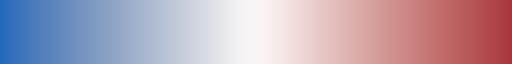

In [41]:
from notebooks.utils.utils import process_model_name

table["K"] = table["k"].apply(lambda x: r"$\text{top}_{" + str(x) + "}$")
table["Model"] = table["model"].apply(process_model_name)
table[r"Size (B)"] = table["Size"].apply(lambda x: str(x).replace("B", ""))

cmap = sns.color_palette("vlag", as_cmap=True)
cmap

In [44]:
date_to_num = lambda x,y: x/12 + y
release_dates = {
    "gemma-4": date_to_num(4,26),
    "Mistral-Small-4": date_to_num(3,26), # 03/26
    "MiniMax-M2": date_to_num(10,25), # 10/25
    "Qwen3-Next": date_to_num(9,25), # 09/25
    "gpt-oss": date_to_num(8,25),# 08/25
    "Qwen3": date_to_num(4,25), # 04/25
    "Llama-3.3": date_to_num(4,25), # 04/25
    "gemma-3": date_to_num(3,25), # 03/25
    "R1-Llama": date_to_num(1,25), # 01/25
    "R1-Qwen": date_to_num(1,25), # 01/25
}

table["date"] = table.Model.apply(lambda x: release_dates.get(x, -1))
corr_df = table[table.date>0].groupby(["Metric", "k", "Model", "date"]).Value.mean().reset_index().groupby(["Metric", "k"])[["Value", "date"]].corr(method="spearman").loc[pd.IndexSlice[:, :, "date"], "Value"]
print(corr_df.reset_index().groupby("k").Value.mean(), corr_df.mean())

In [65]:
size_to_num = lambda x: int(x[:-1]) if not x == "n/a" else 0

table["size_num"] = table.Size.apply(size_to_num)
corr_df = table[table.date>0].groupby(["Metric", "k", "Model", "size_num"]).Value.mean().reset_index().groupby(["Metric", "k"])[["Value", "size_num"]].corr(method="spearman").loc[pd.IndexSlice[:, :, "size_num"], "Value"]
print(corr_df.reset_index().groupby("k").Value.mean(), corr_df.mean())

k
1     0.296354
16    0.126140
Name: Value, dtype: float64 0.21124717642882246


In [ ]:
table = table[table.Model.isin(MODEL_ORDER)]

In [ ]:
def post_process_latex(
    latex: str,
    sep_del=[
        "gemma-4",
        "ether0",
        "RL-Molstral"
    ],
    sep=[
        # r"\multicolumn{" + str(len(N_r)*len(Ks) + 2) + r"}{c}{Random Sampling on ZINC} \\",
        r"\multicolumn{" + str(len(N_r)*len(Ks) + 2) + r"}{c}{General LLMs} \\" ,
        r"\multicolumn{" + str(len(N_r)*len(Ks) + 2) + r"}{c}{Chemically specialized LLMs} \\",
        r"\multicolumn{" + str(len(N_r)*len(Ks) + 2) + r"}{c}{Models trained on MolRGen} \\",

    ]
):
    latex_lines = latex.split("\n")
    new_latex = latex_lines[:3]

    last_header = "&".join(latex_lines[4].split("&")[:2]) + "&" + "&".join(latex_lines[3].split("&")[2:])
    new_latex.append(last_header)
    i_sp = 0
    for line in latex_lines[5:]:
        if r"\midrule" in line:
            continue
        if i_sp < len(sep) and sep_del[i_sp] in line:
            new_latex += [r"\midrule",r"\midrule", sep[i_sp] ,r"\midrule",r"\midrule"]
            i_sp += 1
        new_latex.append(line)
    return "\n".join(new_latex)

In [ ]:
from notebooks.utils import PandasTableFormatter

def color_map(val: float) -> str:
    "Returns a color based on the value (eg '#FF5733')"
    val = 1/(1+np.exp(-3*(val -0.6)))
    color = cmap(val)
    return f"rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})"

formatter = PandasTableFormatter(
    n_decimals = 2, # Number of decimals to keep in the table
    aggregation_methods=["mean", "std"], # Aggregation functions to apply to the data
    main_subset=0, # Subset of values to bold, here the first column will be bolded corresponding to the mean values, if [0,1] the first two columns will be bolded (independently)
    hide_agg_labels=True, # Hide the aggregation column names in the latex
    global_agg=False, # Whether to compute global aggregation across all columns (True)
    color_mapping =color_map,
    groupby_col="prompt_id",
    color_mapping_key_idx=0,
    merge_aggs=True
)

style = formatter.style(
    table, # Dataframe to format
    rows= ["Model", r"Size"], # Rows
    cols=["Metric", r"K"], # Columns
    values= "Value", # Values
    highlight_fn= np.nanmax, # Function to use to highlight the values, here the maximum values will be highlighted
    props=["textbf:--rwrap--latex; underline:--rwrap--latex", "underline:--rwrap--latex",], # Properties to apply to the highlighted values, here the maximum values will be underlined and bolded, the second maximum values will be bolded
    special_format_agg = {
        "std": lambda x: "\\tiny $\\pm$" + x, # Format to apply to the standard deviation values
    },
    remove_col_names=True,
    row_order = MODEL_ORDER
)
latex = post_process_latex(
    formatter.latex(
        style, None, multicol_align="c||", hrules=True, column_format="c|c||" + "".join(["p{1.3cm}" * len(Ks) + "||" for _  in range(len(N_r))])
    )
)

with open(f"{LATEX_PATH}/gen_table.tex", "w") as f:
    f.write(latex)


style

In [ ]:
print(latex)

# Correlation with Prop Pred

In [66]:
df_polaris = pd.read_csv("polaris_res.csv")

In [67]:
df_polaris

,Unnamed: 0,prompt_id,reward,gt,y,norm_var,model,n_props,properties,objectives,validity,Task,match,contains_numeric,Model,Metric
0,0,tdcommons:half-life-obach_train_2,0.734461,1.856298,1.1329,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nTo predict the log-half-life in the human bo...,True,ChemDFM-R,-0.100830
1,1,tdcommons:half-life-obach_train_2,-1.879099,1.856298,-0.5257,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nThe process starts by interpreting the SMILE...,True,ChemDFM-R,-0.100830
2,2,tdcommons:half-life-obach_train_2,-0.512712,1.856298,0.1297,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nThe molecule has a log-half-life (log hr) in...,True,ChemDFM-R,-0.100830
3,3,tdcommons:half-life-obach_train_2,-2.747246,1.856298,-0.8612,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nThe SMILES notation provided for the molecul...,True,ChemDFM-R,-0.100830
4,4,tdcommons:half-life-obach_train_2,-5.549971,1.856298,-1.7365,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nThe process begins by interpreting the SMILE...,True,ChemDFM-R,-0.100830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578077,578077,tdcommons:dili_train_243,1.000000,0.000000,0.0000,0.499915,gemma-4-31B-it,1,tdcommons/dili,classification,True,dili,\boxed{no},False,gemma-4,0.740278
578078,578078,tdcommons:dili_train_243,1.000000,0.000000,0.0000,0.499915,gemma-4-31B-it,1,tdcommons/dili,classification,True,dili,\boxed{no},False,gemma-4,0.740278
578079,578079,tdcommons:dili_train_243,1.000000,0.000000,0.0000,0.499915,gemma-4-31B-it,1,tdcommons/dili,classification,True,dili,\boxed{no},False,gemma-4,0.740278
578080,578080,tdcommons:dili_train_243,1.000000,0.000000,0.0000,0.499915,gemma-4-31B-it,1,tdcommons/dili,classification,True,dili,\boxed{no},False,gemma-4,0.740278


In [68]:
table

,model,Size,Metric,k,Value,prompt_id,K,Model,Size (B),date,size_num
0,ChemDFM-R-14B,14B,$n_r=$16,1,0.772750,107210,$\text{top}_{1}$,ChemDFM-R,14,-1.000000,14
1,ChemDFM-R-14B,14B,$n_r=$16,1,0.000000,10721039070039173-60,$\text{top}_{1}$,ChemDFM-R,14,-1.000000,14
2,ChemDFM-R-14B,14B,$n_r=$16,1,0.000000,10723-106,$\text{top}_{1}$,ChemDFM-R,14,-1.000000,14
3,ChemDFM-R-14B,14B,$n_r=$16,1,0.000000,10723-106390700,$\text{top}_{1}$,ChemDFM-R,14,-1.000000,14
4,ChemDFM-R-14B,14B,$n_r=$16,1,0.797750,109010,$\text{top}_{1}$,ChemDFM-R,14,-1.000000,14
...,...,...,...,...,...,...,...,...,...,...,...
456275,gpt-oss-120b,120B,$n_r=$48,16,0.000000,9103-106,$\text{top}_{16}$,gpt-oss,120,25.666667,120
456276,gpt-oss-120b,120B,$n_r=$48,16,0.599641,94310,$\text{top}_{16}$,gpt-oss,120,25.666667,120
456277,gpt-oss-120b,120B,$n_r=$48,16,0.638719,94610,$\text{top}_{16}$,gpt-oss,120,25.666667,120
456278,gpt-oss-120b,120B,$n_r=$48,16,0.654891,98510,$\text{top}_{16}$,gpt-oss,120,25.666667,120


In [73]:
joined_df = table[table.k==16].rename(columns=dict(Metric = "rollouts")).groupby(["Model", "k"]).Value.mean().reset_index().join(
    df_polaris.groupby([ "Model", "objectives", "Task"]).Metric.mean().reset_index().set_index("Model"), on="Model")

In [74]:
joined_df = joined_df[~joined_df.Metric.isna()]

In [75]:
joined_df

,Model,k,Value,objectives,Task,Metric
0,ChemDFM-R,16,0.420307,classification,ames,0.509001
0,ChemDFM-R,16,0.420307,classification,bbb,0.733879
0,ChemDFM-R,16,0.420307,classification,cyp2c9-substrate,0.484543
0,ChemDFM-R,16,0.420307,classification,cyp2d6-substrate,0.451404
0,ChemDFM-R,16,0.420307,classification,cyp3a4-substrate,0.542647
...,...,...,...,...,...,...
15,gemma-4,16,0.483632,regression,ld50,-0.197243
15,gemma-4,16,0.483632,regression,lipophilicity,0.299069
15,gemma-4,16,0.483632,regression,mic-clearance-az,0.047566
15,gemma-4,16,0.483632,regression,solubility,0.856047


In [72]:
joined_df = joined_df[joined_df.Model != "ether0"]

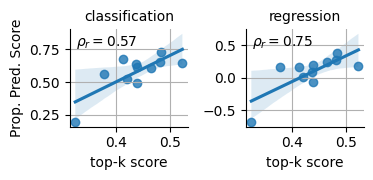

In [77]:
grid = sns.FacetGrid(
    joined_df.groupby(
        ["Model", "objectives"]
    )[
        ["Value", "Metric"]
    ].mean().reset_index(),
    col="objectives",
    height=1.9,
    aspect=1.01,
    sharex=False,
    sharey=False
    # palette=CMAP_MODELS,
    # hue_order=CMAP_MODELS.keys()
)

grid.map_dataframe(
    sns.regplot, x="Value", y="Metric", #hue="Model"
)

def annotate_correlation(data, **kwargs):
    """Add correlation coefficient to each subplot"""
    from scipy.stats import pearsonr, spearmanr
    if len(data) > 1:
        spearman_r, spearman_p = spearmanr(data["Value"], data["Metric"])
        ax = plt.gca()
        ax.text(0.05, 0.95, f"$\\rho_r=${spearman_r:.2f}",
                transform=ax.transAxes, verticalalignment='top',)

grid.map_dataframe(annotate_correlation)

# Adjust titles
grid.set_titles(col_template="{col_name}")
grid.set_axis_labels("top-k score", "Prop. Pred. Score")
for ax in grid.axes.flat:
    ax.grid()

grid.savefig(f"{FIG_PATH}/correlation_prop_pred.pdf", bbox_inches='tight')

In [ ]:
grid = sns.FacetGrid(
    joined_df.groupby(
        ["Model", "objectives", "Task"]
    )[
        ["Value", "Metric"]
    ].mean().reset_index(),
    col="Task",
    col_wrap=5,
    height=2.4,
    aspect=1.01,
    sharex=False,
    sharey=False
    # palette=CMAP_MODELS,
    # hue_order=CMAP_MODELS.keys()
)

grid.map_dataframe(
    sns.regplot, x="Value", y="Metric", #hue="Model"
)

def annotate_correlation(data, **kwargs):
    """Add correlation coefficient to each subplot"""
    from scipy.stats import pearsonr, spearmanr
    if len(data) > 1:
        pearson_r, pearson_p = pearsonr(data["Value"], data["Metric"])
        ax = plt.gca()
        ax.text(0.05, 0.95, f"$\\rho_r=${pearson_r:.2f}",
                transform=ax.transAxes, verticalalignment='top',)

grid.map_dataframe(annotate_correlation)

# Adjust titles
grid.set_titles(col_template="{col_name}")
grid.set_axis_labels("top-k score", "Prop. Pred. Score")
for ax in grid.axes.flat:
    ax.grid()

grid.savefig(f"{FIG_PATH}/correlation_prop_pred_compreh.pdf", bbox_inches='tight')